In [7310]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
import sys
from tqdm import tqdm
sys.path.append("/Users/bipulpandey2004/Desktop/Active_Research/Probability_Outflow_Small_Model/Code/Scripts")
from Compressed_Potts_Outflow import *
from Random_Potts import *
from Frequency_Calculators import *
from Compressed_Potts_sample_generator import *

In [7470]:
##
Num_site = 6

Num_letter = 4
High_value = 0.5
fraction_high = 0.2


In [7471]:
Num_states = Num_letter**Num_site

print("Total Possible States=",Num_states)


if Num_states <100000000:
    States = Construct_States(Num_site, Num_letter)
    States = np.array(States)
    n_s = len(States)
    if Num_states == n_s:
        print("NUmber of States match!")
else:
    print("Should we construct all states?")



Unfurled_States =[]

for elem in States:
    unf_elem = One_hot_encoder(elem, Num_letter)
    Unfurled_States.append(unf_elem)
Unfurled_States = np.array(Unfurled_States)



Total Possible States= 4096
Constructing all states
Number of States from Construction= 4096
NUmber of States match!


In [7472]:
Weight_GT, Bias_GT = Potts_Parameter_Creator(Num_site, Num_letter, High_value, fraction_high)

Number of High values= 240


In [7473]:
Energy_of_States = Potts_Energy_of_State_Array(Unfurled_States, Weight_GT, Bias_GT)

In [7474]:
Temperature = 1
Probability_of_States = Potts_Probability_of_State_Array(Energy_of_States, Temperature)

Text(0.5, 1.0, 'Probability')

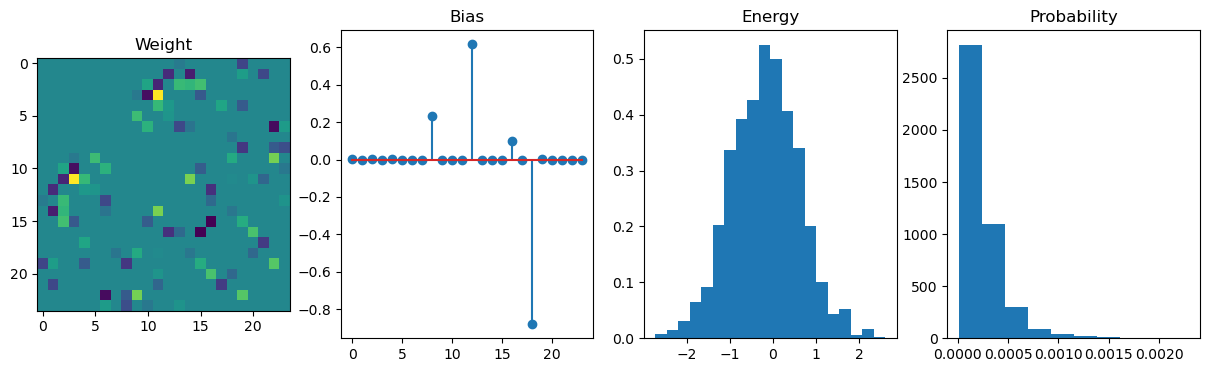

In [7475]:
fig, ax = plt.subplots(1,4, figsize=(15,4))
ax[0].imshow(Weight_GT)
ax[1].stem(Bias_GT)
ax[2].hist(Energy_of_States, bins = 20, density = True)
ax[3].hist(Probability_of_States,bins=10, density = True)
ax[0].set_title("Weight")
ax[1].set_title("Bias")
ax[2].set_title("Energy")
ax[3].set_title("Probability")

In [7476]:
Sample_Size = [1,2,5,7,10,20,50,70,100,200,300,500,700,900,1000,2000,3000,4000,5000,6000,7000,9000,10000,15000, 20000, 30000]

Sampling_Experiment={}
for elem in Sample_Size:
    Sampling_Experiment[elem] = Sample_From_Distribution(elem, States, Probability_of_States)

In [7477]:
### 
Num_unique = []
for elem in Sample_Size:
    Exp_elem = Sampling_Experiment[elem]
    Emp_prob = Exp_elem["Empirical_Probability_for_unique"]

    Num_unique.append(len(Emp_prob))

In [7478]:
Emp_Entropy_Array=[]
GT_Entropy_Array= []
for elem in Sample_Size:
    Exp_elem = Sampling_Experiment[elem]
    Emp_prob = Exp_elem["Empirical_Probability_for_unique"]
    GT_prob = Exp_elem["Ground_Truth_Probability_for_unique"]

    GT_prob_norm = np.sum(GT_prob)
    GT_prob/=GT_prob_norm

    Emp_Entropy= -1*np.sum(Emp_prob* np.log(Emp_prob))
    GT_Entropy = -1*np.sum(GT_prob* np.log(GT_prob))

    Emp_Entropy_Array.append(Emp_Entropy)
    GT_Entropy_Array.append(GT_Entropy)



In [7479]:
Actual_Entropy_GT = np.sum(-1*Probability_of_States * np.log(Probability_of_States))

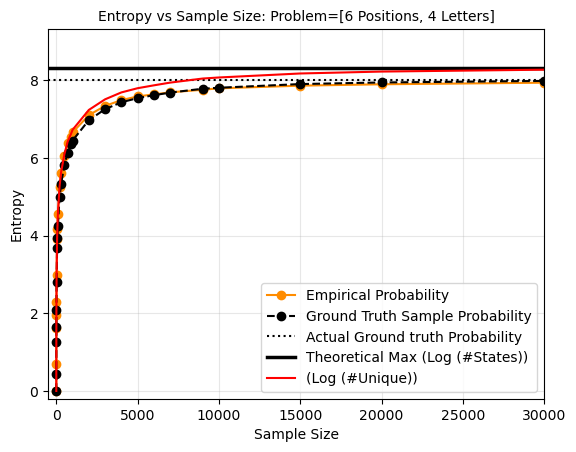

In [7480]:
plt.plot(Sample_Size,Emp_Entropy_Array, "o-", color = "darkorange", label = "Empirical Probability")
plt.plot(Sample_Size,GT_Entropy_Array, "o--", color = "black", label = "Ground Truth Sample Probability")
plt.axhline(Actual_Entropy_GT, color ="black", linestyle = "dotted" ,label = "Actual Ground truth Probability")
plt.xlabel("Sample Size")
plt.ylabel("Entropy")
plt.title(f"Entropy vs Sample Size: Problem=[{Num_site} Positions, {Num_letter} Letters]", fontsize = 10)
plt.axhline(np.log(Num_states), color = "black", linewidth = 2.5, label = "Theoretical Max (Log (#States))")

#plt.plot(Sample_Size, np.log(Sample_Size),label = " Log (# Samples)")
plt.plot(Sample_Size, np.log(Num_unique), color = "red",label ="(Log (#Unique))")
plt.ylim(-0.2,np.log(Num_states)+1)
plt.grid(alpha = 0.3)
plt.xlim(-500,30000)
plt.legend()

In [7481]:
Correction_MM = (np.array(Num_unique)-1)/(2* np.array(Sample_Size))

S_corr = Emp_Entropy_Array - Correction_MM

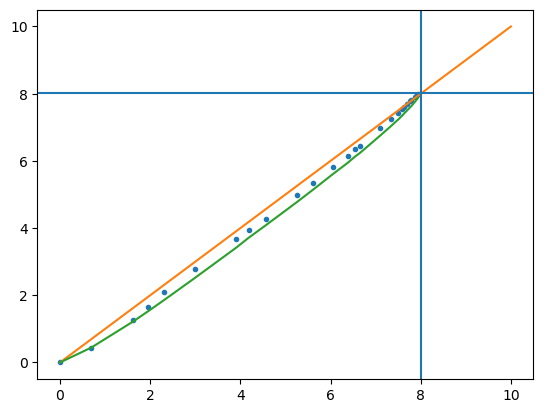

In [7482]:
plt.plot(Emp_Entropy_Array,GT_Entropy_Array, ".")
plt.plot(np.arange(0,11,1), np.arange(0,11,1))

plt.plot(Emp_Entropy_Array , S_corr)

plt.axvline(Actual_Entropy_GT)
plt.axhline(Actual_Entropy_GT)

In [7483]:
def estimate_GT_sample_entropy(multiplicities, N):
    M    = len(multiplicities)
    p    = multiplicities / N
    H_emp = -np.sum(p * np.log(p + 1e-300))
    n1   = np.sum(multiplicities == 1)
    f1   = (n1-1) / (N)
    
    # missing mass correction (dominant)
    missing_correction  = f1 * H_emp
    # variance correction (Miller-Madow)
    variance_correction = (M -1) / (2 * N)
    
    H_target = H_emp - missing_correction - variance_correction
    
    return H_target, H_emp, f1 , variance_correction

U, C = np.unique(Chosen_Data, axis = 0, return_counts= True)

A = estimate_GT_sample_entropy(C, np.sum(C))
print(A)

(np.float64(1.4761696021842665), np.float64(6.32056534061422), np.float64(0.7), np.float64(0.42))


In [7484]:
P = []
Q = []
R = []
Sugg = []
f_val = []
MM_corr_val = []
for m in range(0, len(Sample_Size)):
    n = Sample_Size[m]
    Chosen_indices_m= Sampling_Experiment[n]['Indices_Picked']
    Chosen_Data_m = Sampling_Experiment[n]['Chosen_Compact_States']
    U, C = np.unique(Chosen_Data_m, axis = 0, return_counts= True)
    A_m = estimate_GT_sample_entropy(C, np.sum(C))

    Sing_corr = A_m[1] - (A_m[2])
    MM_corr = A_m[1] - A_m[3]
    MM_corr_act = Sing_corr + A_m[3]

    P.append(Sing_corr)
    Q.append(MM_corr)
    R.append(MM_corr_act)
    Sugg.append(A_m[0])
    f_val.append(A_m[2])
    MM_corr_val.append(A_m[3])


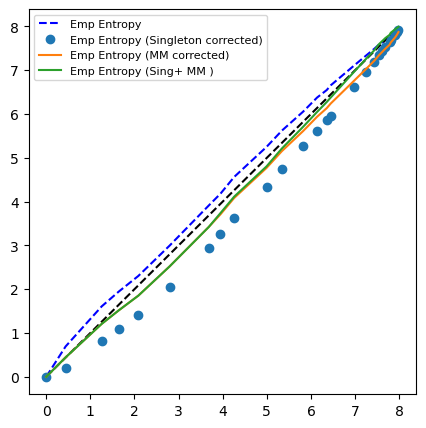

In [7485]:
#C = np.array(Emp_Entropy_Array) - 0.5* (((Num_letter** Num_site - np.array(Num_unique))/(Num_letter** Num_site) ) * (f_val) + np.array(MM_corr_val))

plt.figure(figsize=(5,5))
plt.plot(GT_Entropy_Array, Emp_Entropy_Array, "b--", label = "Emp Entropy")
plt.plot(GT_Entropy_Array, GT_Entropy_Array, "k--")
plt.plot(GT_Entropy_Array, P, "o",  label = "Emp Entropy (Singleton corrected)")
plt.plot(GT_Entropy_Array, Q, label = "Emp Entropy (MM corrected)")
plt.plot(GT_Entropy_Array, R, label = "Emp Entropy (Sing+ MM )")

#plt.plot(GT_Entropy_Array, C , label = "Exp")
plt.legend(fontsize = 8)


No Correction= 0.18918772527279581
Sing. Correction= 0.45264271858004296
MM . Correction= 0.19194611321584704
MM+ Sing Corr= 0.1214854575842459


Text(0.5, 1.0, 'Entropy Correction: Problem=[6 Positions, 4 Letters]')

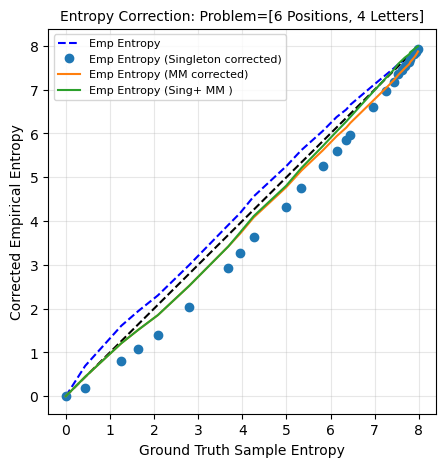

In [7486]:
plt.figure(figsize=(5,5))
plt.plot(GT_Entropy_Array, Emp_Entropy_Array, "b--", label = "Emp Entropy")
plt.plot(GT_Entropy_Array, GT_Entropy_Array, "k--")
plt.plot(GT_Entropy_Array, P, "o",  label = "Emp Entropy (Singleton corrected)")
plt.plot(GT_Entropy_Array, Q, label = "Emp Entropy (MM corrected)")
plt.plot(GT_Entropy_Array, R, label = "Emp Entropy (Sing+ MM )")

plt.xlabel("Ground Truth Sample Entropy")
plt.ylabel("Corrected Empirical Entropy")
plt.grid(alpha = 0.3)
plt.legend(fontsize = 8)


print("No Correction=",np.sqrt(np.mean((np.array(GT_Entropy_Array) - np.array(Emp_Entropy_Array))**2)))
print("Sing. Correction=",np.sqrt(np.mean((np.array(GT_Entropy_Array) - np.array(P))**2)))
print("MM . Correction=",np.sqrt(np.mean((np.array(GT_Entropy_Array) - np.array(Q))**2)))
print("MM+ Sing Corr=",np.sqrt(np.mean((np.array(GT_Entropy_Array) - np.array(R))**2)))
plt.title(f"Entropy Correction: Problem=[{Num_site} Positions, {Num_letter} Letters]", fontsize = 10)



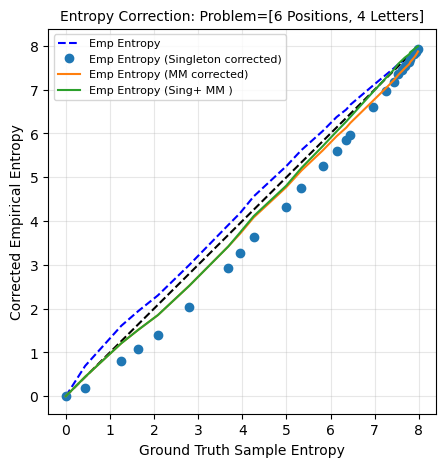

In [7553]:
plt.figure(figsize=(5,5))
plt.plot(GT_Entropy_Array, Emp_Entropy_Array, "b--", label = "Emp Entropy")
plt.plot(GT_Entropy_Array, GT_Entropy_Array, "k--")
plt.plot(GT_Entropy_Array, P, "o",  label = "Emp Entropy (Singleton corrected)")
plt.plot(GT_Entropy_Array, Q, label = "Emp Entropy (MM corrected)")
plt.plot(GT_Entropy_Array, R, label = "Emp Entropy (Sing+ MM )")
plt.title(f"Entropy Correction: Problem=[{Num_site} Positions, {Num_letter} Letters]", fontsize = 10)

plt.xlabel("Ground Truth Sample Entropy")
plt.ylabel("Corrected Empirical Entropy")
plt.grid(alpha = 0.3)
plt.legend(fontsize = 8)

num_unique = 282
300
Sample Size= 300


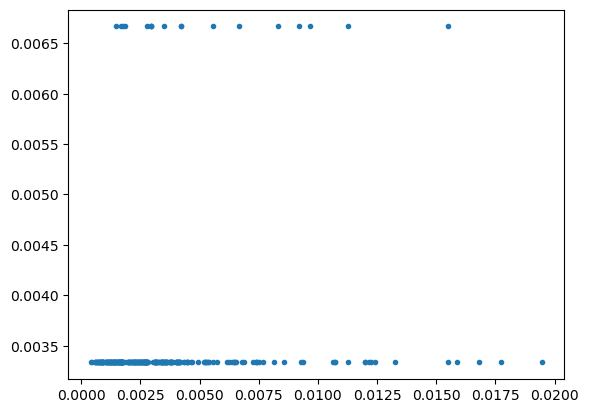

In [7703]:
st = 10
k = Sample_Size[st]

Chosen_indices = Sampling_Experiment[k]['Indices_Picked']
Chosen_Data = Sampling_Experiment[k]['Chosen_Compact_States']

Emp_prob_k = Sampling_Experiment[k]['Empirical_Probability_for_unique']
GT_prob_k = Sampling_Experiment[k]['Ground_Truth_Probability_for_unique']
Unique_index = Sampling_Experiment[k]['Unique_indices']
print("num_unique =", len(Unique_index))

print(len(Chosen_Data))

print("Sample Size=", k)
plt.plot(Sampling_Experiment[k]["Ground_Truth_Probability_for_unique"], Sampling_Experiment[k]["Empirical_Probability_for_unique"], ".")

In [7704]:
from scipy.stats import pearsonr

In [7705]:
import numpy as np
from tqdm import tqdm


#######
class Compressed_Potts_Quadratic:
    def __init__(self, Compact_Training_Data, Partition_Map = None, Influence = True, extra_character = "zz?",Temperature =1 ,noise = 1e-8, compressed= True):

        self.compact_data = Compact_Training_Data.copy()

        self.Total_data_size = len(Compact_Training_Data)
        self.num_of_positions = np.shape(Compact_Training_Data)[1]

        self.alphabet_list = np.unique(self.compact_data)
        self.total_alphabet_size = len(self.alphabet_list)
        self.compress = compressed #<=if false, we will not use compressed
        self.Influence = Influence
        self.Temperature = Temperature
        self.noise = noise
        
        ###
        if self.compress:
            # we need to introduce extra character
            self.extra_character = self.alphabet_list[-1] *2
            #self.extra_character = extra_character
            self.Check_type()
        self.compressed_alphabet_size , self.conversion_dictionary = self.Compressed_dictionary()
        self.num_of_positions = len(self.compressed_alphabet_size)

        ###-- constructing the list of indices for each position ---
        self.Position_index = self.Position_index_finder()

   
        ### construct fundamental connectivity and weights and biases
        #self.Init_Boltzmann_Parameters()

        ### --
        ## -- unfurling the data and building lookup tables ---
        self.unfurled_data = self.Unfurled_dataset(self.compact_data)
                ## finding the unique data points and data multiplicity 
        ##### assigning the unique data and multiplicity to respective class properties
        self.Unique_datapoints, self.Data_multiplicity, self.unique_data_args = self.Unique_data_finder(self.unfurled_data)

        ###------- Partition Setup ----- 
        if type(Partition_Map)==type(None):
            ### assume all-all connected
            self.Raw_Partition_Map = np.ones(self.num_of_positions).reshape(1,-1)
            self.num_of_partitions = 1
        else:
            self.Raw_Partition_Map = Partition_Map.copy()
            self.num_of_partitions = len(Partition_Map)
        print("Number of Partitions Set=", self.num_of_partitions)

        self.Partition_Map_Setter(self.Raw_Partition_Map)

            
        self.data_lookup, self.full_data_Hash_values = self.build_lookup_structure(self.unfurled_data)

        #self.Init_Boltzmann_Parameters_ver2()
        self.Init_ScoreMatching_Scaled()


        ### Gauge fix
        for p in range(0, self.num_of_partitions):
            self.Bias[p] = self.Bias_Gauge_Fixing(p)



    ### ----------- Helpers --------

    def build_lookup_structure(self, Data_Array):
        """Build optimized lookup structure once
        - For each UNIQUE data point as keys
        - the value will hold the probabilty (frequency/total_data_points)"""
        lookup = {}

        ## this contains hash values for all data points
        Hash_values = []

        length_of_data = len(Data_Array)
        for i, seq in enumerate(Data_Array):
            #hash(tuple(seq)) for memory efficiency
            # tuple(seq) is pretty inefficient
            key = hash(tuple(seq)) 
            Hash_values.append(key)
            if key in lookup:
                lookup[key] += 1
            else:
                lookup[key] = 1
        #return lookup, np.array(Hash_values)
        sorted_lookup_dict = dict(sorted(lookup.items()))
        Hash_values_sorted = np.array(list(sorted_lookup_dict.keys()))



        return sorted_lookup_dict, Hash_values_sorted
    

    def Hash_Value_given_data(self, Data_point):
        Value = hash(tuple(Data_point))
        return Value

    #def Hash_Values_batch(self, Data_points):
    #    """Batch hash computation for multiple data points"""
    #    # Method 1: Pure Python (good balance)
    #    return [hash(tuple(dp)) for dp in Data_points]
    
    def Hash_Values_batch(self, Data_points):
        """Fastest for pure Python"""
        return list(map(lambda dp: hash(tuple(dp)), Data_points))


    def Position_index_finder(self):
        """Constructs a dictionary of indices for each position in the one-hot encoded space"""
        Position_index = {}
        start_p = 0
        for p in range(0, len(self.compressed_alphabet_size)):
            end_p = start_p + self.compressed_alphabet_size[p]
            Position_index[p] = np.arange(start_p, end_p)
            start_p = end_p
        return Position_index
    

    def Unique_data_finder(self, Data):

        Data_Dict, datapoint_hash = self.build_lookup_structure(Data)
        #Unique_datapoint_hash = list(Data_Dict.keys())

        #Unique_datapoint_hash = np.array(list(Data_Dict.keys()))
        unique_datapoint_args = []
        for h in Data_Dict.keys():
            a_h = (np.argwhere(datapoint_hash==h)[0])
            unique_datapoint_args.append(a_h)
        unique_datapoint_args = np.array(unique_datapoint_args).reshape(-1)

        Multiplicity = np.array(list(Data_Dict.values()))
        Unique_datapoints  = Data[unique_datapoint_args]
        return Unique_datapoints, Multiplicity , unique_datapoint_args
        

    def Check_type(self):
        if self.extra_character not in self.alphabet_list:
            print("extra character=",self.extra_character )
            print("last alphabet =" , self.alphabet_list[-1])
            print("Extra character is okay.")

        else:
            ## last character is probably 0.
            m = np.random.randint(0, self.total_alphabet_size ,1)

            self.extra_character = self.alphabet_list[-1] +  self.alphabet_list[m]

            print("internal extra character was off")
            print("new extra character=",self.extra_character )
            print("last alphabet =" , self.alphabet_list[-1])
            self.Check_type()


    def Compressed_dictionary(self):
        ## will we compress it or not
        compression_status = self.compress

        dimension =[]
        conversion_dictionary ={}
        if compression_status:
            # we will compress it
            for i,c in enumerate(self.compact_data.T):
                unique_i = np.unique(c)
                dim_i = len(unique_i)+1
                unique_i = np.concatenate((unique_i, [self.extra_character]))
                conversion_dictionary[i] = unique_i
                dimension.append(dim_i)
        else:
            # we will not compress 
            Unique_set = self.alphabet_list
            for i in range(0, self.num_of_positions):
                unique_i = Unique_set
                dim_i = len(unique_i)
                conversion_dictionary[i] = Unique_set
                dimension.append(dim_i)

        return np.array(dimension), conversion_dictionary
    
    

    def Partition_Map_Setter(self, Raw_Partition_Map):
        print("..Setting Partition Map..")
        print("Number of partitions =", len(Raw_Partition_Map))

        """Sets the raw partition map
        - For each partition in the raw partitions, 
        constructs a list of indices pertaining to data in that partition in 1-hot encoded bases"""

        self.Raw_Partition_Map = Raw_Partition_Map

        Connected_indices ={}
        for i,part_i in enumerate(Raw_Partition_Map):
            Arg_p = np.argwhere(part_i==1).reshape(-1)
            conn_p =[]
            for a in Arg_p:
                conn_p.append(self.Position_index[a])

            conn_p = np.concatenate(conn_p)
            Connected_indices[i] = conn_p

        self.Partition_Map = Connected_indices
        #self.Init_Boltzmann_Parameters_ver2()
        
        self.Init_ScoreMatching_Scaled()

        self.Hash_Value_by_partition, self.Lookup_table_by_partition = self.Partitioned_Data_Lookup_table()
        
        self.Mutant_weight = self.Mutant_representation_weights()



    def One_hot_encoder(self, Compact_state):
        """For any given state, it returns a one hot encoded state
        - unseen words at any position are mapped to unknown"""
        Dictionary = self.conversion_dictionary
        Dim = self.compressed_alphabet_size
        Full_Vector = []
        for i,word_i in enumerate(Compact_state):
            dim_i = Dim[i]
            Dict_i = Dictionary[i]
            Sub_vector = np.zeros(dim_i)

            try:
                arg_one = (np.argwhere(Dict_i==word_i).reshape(-1))
            except:
                ## word out of vocabulary. Map it to unknown
                arg_one = (np.argwhere(Dict_i==self.extra_character).reshape(-1))

            Sub_vector[arg_one] =1
            Full_Vector.append(Sub_vector)
        Full_Vector = np.concatenate(Full_Vector)
        return Full_Vector
    


    def One_hot_decoder(self, Unfurled_state):
        """for any one hot encoded state, it returns the compact state
         (list of words that make the sentence)"""
        Dictionary = self.conversion_dictionary
        Dim = self.compressed_alphabet_size
        Compact_state = []
        start_index = 0
        end_index = 0
        for i, dim_i in enumerate(Dim):
            end_index += dim_i
            Dict_i = Dictionary[i]
            sub_vector = Unfurled_state[start_index:end_index]
            arg_one= np.argwhere(sub_vector==1).reshape(-1)
            word_i = Dict_i[arg_one]
            start_index += dim_i
            Compact_state.append(word_i)

        return np.array(Compact_state).reshape(-1)

    def Unfurled_dataset(self, Data):
        """Takes any compact dataset and writes it in a one-hot encoded compressed basis
        - Compressed meaning all the words never seen at a position are mapped to a single position in one hot encoded vector for that word"""
        Full_set = []
        for d in Data:
            unf_d = self.One_hot_encoder(d)
            Full_set.append(unf_d)
        return np.array(Full_set)


    
    def Fundamental_Connectivity(self):

        Partition_Map_dict = self.Partition_Map
        Position_index = self.Position_index
        Raw_partition = self.Raw_Partition_Map
        Influence = self.Influence

        ### this doesn't have zeroing out of the diagonals

        Fundamental_connectivity_dict = {}
        partitions = list(Partition_Map_dict.keys())

        for p in partitions:
            #raw_part = Raw_partition[p]
            #positions_p = np.argwhere(raw_part==1).reshape(-1)
            Total_dof_p_row = len(Partition_Map_dict[p])
            Total_dof_p_col = Total_dof_p_row
            Total_dof_prev = 0

            if p > 0 and Influence:
                Total_dof_prev = len(Partition_Map_dict[p-1])
                Total_dof_p_col+=Total_dof_prev

            FC_p = np.ones((Total_dof_p_row, Total_dof_p_col))

            Fundamental_connectivity_dict[p] = FC_p

        ### Now we zero out the appropriate blocks that correspond to self interaction.
        for idx in partitions:
            Raw_part = Raw_partition
            full_part = Partition_Map_dict
            Position_index = Position_index
            Super_offset = 0
            if idx>0 and Influence:
                Super_offset = len((full_part[idx-1]).reshape(-1))
            arg_part = np.argwhere(Raw_part[idx]==1).reshape(-1)
            len_part = len(full_part[idx])
            offset = 0
            FC_i = Fundamental_connectivity_dict[idx]
            for p in arg_part:
                #print(p)
                args_p = np.arange(0,len(Position_index[p])) + offset 
                args_p_col = args_p + Super_offset

                #print(len(args_p))
                #print(np.shape(FC))
                v1 = np.zeros(len_part) 
                v1[args_p] = 1

                v2 = np.zeros(Super_offset+len_part)
                v2[args_p_col] = 1
                
                Matrix = np.outer(v1, v2)
                offset += len(Position_index[p])
                FC_i-= Matrix
        
        
        
        return Fundamental_connectivity_dict

             
    def Mutant_representation_weights(self):
        """ Gives weights of mutants for suppression
         - If a mutant is a such that it has been observed in the data , weight =1
         - If the mutant is such that it represents all unseen words at a given position (the filler), weight = Size of unseen words
         """

        Num_part = len(self.Raw_Partition_Map)
        Mu_Rep_wt = {}

        for Partition_index in range(0, Num_part):
            Map = self.Raw_Partition_Map[Partition_index]
            Args_one =np.argwhere(Map==1).reshape(-1)

            Compressed_alphabets = self.compressed_alphabet_size[Args_one]

            Indices = np.cumsum(Compressed_alphabets) -1

            Mu_weights = np.ones(np.sum(Compressed_alphabets))

            Remaining = self.total_alphabet_size -  Compressed_alphabets 

            Mu_weights[Indices] = Remaining
            Mu_Rep_wt[Partition_index] = Mu_weights

        return Mu_Rep_wt

    

    def Data_part_by_index(self, partition_index):
        """Partitions the Unique Data on the given partition
        Input:
        partition_index(int): from 0 to len(Partition)
        """
        partition_index = int(partition_index)
        Data = self.Unique_datapoints
        Part_args = self.Partition_Map[partition_index]
        Data_part = Data[:,Part_args]
        return Data_part
    
    def Data_part(self):
        Partitions = list(self.Partition_Map.keys())
        Partitioned_Data = {}

        for p in Partitions:
            Partitioned_Data[p] = self.Data_part_by_index(p)
        return Partitioned_Data
    
    def Data_Partition(self, Data, partition_index):
        #Data = self.Unique_datapoints
        padded = False
        if len(np.shape(Data)) ==1:
            ## we will need to pad the other dimension for slicing
            Data = Data.reshape(1,-1)
            padded = True

        Row_args = self.Partition_Map[partition_index]

        if self.Influence and partition_index>0:
            Col_args = np.concatenate([self.Partition_Map[partition_index-1],self.Partition_Map[partition_index]])

        else:
            Col_args = self.Partition_Map[partition_index]

        Data_self = Data[:, Row_args]
        Data_interaction = Data[:, Col_args]

        if padded==True:
            Data_self = Data_self.reshape(-1)
            Data_interaction = Data_interaction.reshape(-1)

        return Data_self, Data_interaction
    
    def Partitioned_Data_Lookup_table(self):
        Hash_values_by_partition = {}
        Lookup_tables_by_partition = {}
        # --- NEW ---
        Hash_values_by_partition_self = {}
        Lookup_tables_by_partition_self = {}
        # -----------

        for p in range(0, self.num_of_partitions):
            Data_in_partition_self, Data_in_partition_with_influence = self.Data_Partition(self.unfurled_data, p)

            Lookup_table_p, Hash_values_p = self.build_lookup_structure(Data_in_partition_with_influence)
            Hash_values_by_partition[p] = Hash_values_p
            Lookup_tables_by_partition[p] = Lookup_table_p

            # --- NEW: build self-only lookup ---
            Lookup_table_self_p, Hash_values_self_p = self.build_lookup_structure(Data_in_partition_self)
            Hash_values_by_partition_self[p] = Hash_values_self_p
            Lookup_tables_by_partition_self[p] = Lookup_table_self_p

        # Store both
        self.Hash_Value_by_partition_self = Hash_values_by_partition_self
        self.Lookup_table_by_partition_self = Lookup_tables_by_partition_self

        return Hash_values_by_partition, Lookup_tables_by_partition

    
    ######################### Different types of initializations

    def Init_Boltzmann_Parameters(self):
        """
         -Initialize with symmetric W_self
         - Layer mutant energy calculation can be made faster with BLAS routine for symmetric matrix
        """

        
        FC = self.Fundamental_Connectivity()
        self.fundamental_connectivity = FC
        
        Partitions = list(FC.keys())
        Weights = {}
        Bias = {}
        
        Data_mean = np.mean(self.unfurled_data, axis=0)
        
        for p in Partitions:
            Row_size, Col_size = np.shape(FC[p])
            Weight_p = np.random.normal(loc=0, scale=100*self.noise, size=(Row_size, Col_size))
            Weight_p *= FC[p]
            
            # ============================================================
            # Make W_self symmetric (3 lines)
            # ============================================================
            split_idx = (Col_size - Row_size) if (self.Influence and p > 0) else 0
            W_self = Weight_p[:, split_idx:]
            Weight_p[:, split_idx:] = (W_self + W_self.T) / 2
            # ============================================================
            
            p_indices = self.Partition_Map[p]
            #Data_mean_p = Data_mean[p_indices] * (-0.01)
            frequencies = np.clip(Data_mean[p_indices], 1e-5, 1)
            Bias_p = self.Temperature * np.log(frequencies) * 1e-5
            Bias_p += np.random.normal(loc=0, scale=self.noise, size=Row_size)
            
            
            Weights[p] = Weight_p
            Bias[p] = Bias_p
        
        self.Weights = Weights
        self.Bias = Bias
        
        self.Data_Partitioned = self.Data_part()
        self.partition_multiplicity_arg_dict = self.Data_arg_multiplicity_dictionary_constructor(self.unfurled_data)
    
    def Init_Boltzmann_Parameters_ver2(self):
        """
         -Initialize with symmetric W_self
         - Layer mutant energy calculation can be made faster with BLAS routine for symmetric matrix
        """
        print("semi-warm start. Matching only the frequencies")
        FC = self.Fundamental_Connectivity()
        self.fundamental_connectivity = FC
        
        Partitions = list(FC.keys())
        Weights = {}
        Bias = {}
        
        Data_mean = np.mean(self.unfurled_data, axis=0)
        
        for p in Partitions:
            Row_size, Col_size = np.shape(FC[p])
            p_indices = self.Partition_Map[p]
            
            # Initializing bias from frequencies
            frequencies = np.clip(Data_mean[p_indices], 1e-8, 1.0)
            Bias_p = self.Temperature * np.log(frequencies)
            
            # Measure typical bias magnitude
            bias_magnitude = np.mean(np.abs(Bias_p))
            
            # Initialize weights to be 20% of bias magnitude
            # This allows weights to have effect without dominating
            weight_std = 0.05 * bias_magnitude  # Adjust 0.2 to 0.1-0.5 as needed
            
            Weight_p = np.random.normal(loc=0, scale=weight_std, size=(Row_size, Col_size))
            Weight_p *= FC[p]
            
            # Make W_self symmetric
            split_idx = (Col_size - Row_size) if (self.Influence and p > 0) else 0
            W_self = Weight_p[:, split_idx:]
            Weight_p[:, split_idx:] = (W_self + W_self.T) / 2
            
            # Add tiny noise to bias for symmetry breaking
            Bias_p += np.random.normal(loc=0, scale=self.noise, size=Row_size)
            
            Weights[p] = Weight_p
            Bias[p] = Bias_p * 0.1
        
        self.Weights = Weights
        self.Bias = Bias



    def Init_ScoreMatching_Scaled(self):
        """
        FINAL RECOMMENDATION: Score matching / pseudolikelihood (same thing!)
        
        This is the analytical solution - no sklearn, no class balance issues
        """
        
        print("Initializing with score matching ...")


        
        Data = self.unfurled_data
        N = len(Data)
        Data_mean = np.mean(Data, axis=0)
        
        # Compute correlations
        Correlation = (Data.T @ Data) / N
        Connected_Corr = Correlation - np.outer(Data_mean, Data_mean)
        
        
        FC = self.Fundamental_Connectivity()
        self.fundamental_connectivity = FC
        
        Weights = {}
        Bias = {}
        
        for p in range(self.num_of_partitions):
            p_indices = self.Partition_Map[p]
            
            if self.Influence and p > 0:
                prev_indices = self.Partition_Map[p-1]
                all_indices = np.concatenate([prev_indices, p_indices])
            else:
                all_indices = p_indices
            
            C_block = Connected_Corr[np.ix_(p_indices, all_indices)]
            
            # Weights from correlations (pseudolikelihood analytical solution)
            Weight_p = -C_block / (1 + 0.1)
            Weight_p *= FC[p]
            
            # Bias from frequencies
            frequencies = np.clip(Data_mean[p_indices], 1e-8, 1.0)
            #Bias_p = self.Temperature * np.log(frequencies)
            Bias_p = -1*frequencies 
        
            
            # Make W_self symmetric
            Row_size, Col_size = Weight_p.shape
            split_idx = (Col_size - Row_size) if (self.Influence and p > 0) else 0
            W_self = Weight_p[:, split_idx:]
            Weight_p[:, split_idx:] = (W_self + W_self.T) / 2
            
            Bias_p += np.random.normal(loc=0, scale=self.noise, size=len(p_indices))
            
            Weights[p] = Weight_p
            Bias[p] = Bias_p
        
        self.Weights = Weights
        self.Bias = Bias


        

    #############
    def Bias_Gauge_Fixing(self, partition_index):
        Bias = self.Bias[partition_index].copy()
        partition_indices = np.argwhere(self.Raw_Partition_Map[partition_index]==1).reshape(-1)
        Alphabet_sizes= self.compressed_alphabet_size
        current_idx = 0

        Bias_new = np.zeros_like(Bias)
        for i in partition_indices:
            start_index = current_idx
            end_index = current_idx + Alphabet_sizes[i]
            Bias_i = Bias[start_index:end_index]
            Mean_i = np.mean(Bias_i)
            
            Bias_new[start_index:end_index] = Bias_i - Mean_i
            ## shift current to next position
            current_idx+=Alphabet_sizes[i]
        return Bias_new
    

    ### ----------- Energy Calculators -----------
    def Energy_Array_given_partition(self, Weight_part, Bias_part, Data_self, Data_interaction):
        """Calculates energy for an Array using partitioned weight/bias matrices"""

        Energy_all = np.sum(Data_self @ Weight_part * Data_interaction , axis = 1) + Data_self@Bias_part
        return Energy_all
    
    def Energy_Mutant_Array(self, Weight_part, Bias_part, Mutant_self_full, Mutant_interact_full):
        """Calculates energy for a Mutant Array using partitioned weight/bias matrices
        - This needs to have mutant arrays otherwise it doesn't work
        - Speed comes from the fact that the influencing piece for all Mutant is the same
        - Hence calculation can be fragmented into self energy + influence energy"""
        a,b = np.shape(Weight_part)
        W_self = Weight_part[:,(b-a):]
        W_interact = Weight_part[:, 0:(b-a)]
        #print(np.shape(W_self))
        #print(np.shape(W_interact))
        D_prev = Mutant_interact_full[0][0:(b-a)]

        Bias_Influence = (W_interact@D_prev) + Bias_part

        E_total = np.sum(Mutant_self_full @ W_self * Mutant_self_full, axis =1) + Mutant_self_full@Bias_Influence
        
        return E_total
        
    def Energy_Mutant_Array_Split(self, Weight_part, Bias_part,  Mutant_self_full, Mutant_interact_full):
        """
        Returns self-energy and interaction-energy separately.
        E_total = E_self + E_interact (+ bias, attributed to self)
        """
        a, b = np.shape(Weight_part)
        W_self     = Weight_part[:, (b-a):]
        W_interact = Weight_part[:, 0:(b-a)]
        D_prev     = Mutant_interact_full[0][0:(b-a)]

        # Self energy: quadratic term + bias (no influence from x_prev)
        E_self    = np.sum(Mutant_self_full @ W_self * Mutant_self_full, axis=1) \
                    + Mutant_self_full @ Bias_part

        # Interaction energy: how x_prev modulates x_curr
        E_interact = Mutant_self_full @ (W_interact @ D_prev)

        E_total = E_self + E_interact

        return E_self, E_interact, E_total


    def Energy_state_given_partition(self, Unfurled_Sequence, partition_index):
        
        """Calculates energy for a sequence using partitioned weight/bias matrices"""

        Data_self, Data_interaction = self.Data_Partition(Unfurled_Sequence, partition_index)

        Weight = self.Weights[partition_index]
        Bias = self.Bias[partition_index]
        
        Energy_Sequence = np.dot(Data_self @ Weight, Data_interaction) + np.dot(Bias, Data_self)
        
        return Energy_Sequence
    
    #####-------------------------------------
    
    def Data_Partition_args_and_multiplicity(self, Data, partition_index):
        Data_Self, Data_Interaction = self.Data_Partition(Data, partition_index)
        Data_interact_unique, Multiplicity_unique, Arg_unique = self.Unique_data_finder(Data_Interaction)
        return Data_interact_unique, Multiplicity_unique, Arg_unique
    
    def Data_arg_multiplicity_dictionary_constructor(self, Data):
        
        Full_arg_multiplicity_dict={}

        for p in range(0, len(self.Raw_Partition_Map)):
            p_dict ={}
            _, mult_p, arg_p = self.Data_Partition_args_and_multiplicity(Data,p)
            p_dict["Multiplicity"] = mult_p
            p_dict["Args"] = arg_p

            Full_arg_multiplicity_dict[p] = p_dict
            
        return Full_arg_multiplicity_dict
    
    
    ### --------- Constructing Mutants -----------

    def Single_Mutants_Generator(self, Unfurled_Sequence, partition_index, weighted_out_mutants=False):


        ## split the sequence into self and interaction components for this partition:
        Data_self, Data_interaction = self.Data_Partition(Unfurled_Sequence, partition_index)
        Diff = len(Data_interaction) - len(Data_self)

        Connectivity_partition = self.fundamental_connectivity[partition_index]

        Part_dof = len(Data_self)

        
        Args_zero =np.ravel(np.argwhere(Data_self==0))

        num_mutants = len(Args_zero)

        ### purely prev partition data:
        Data_prev_part = Data_interaction[:Diff]
        
        ## check to see 

        Connectivity_relevant = Connectivity_partition[:, Diff:]

        #Single_mutant_full_self = ((Connectivity_relevant * Data_self) + np.eye(Part_dof))

        ## we will remove all the copies of the datapoint from this mutant list
        ## this is done by selecting only 'Arg_zeros' mutants
        Single_mutant_self =  ((Connectivity_relevant * Data_self) + np.eye(Part_dof))[Args_zero]


        if weighted_out_mutants==False:
            Mutant_weight = np.ones(len(Single_mutant_self))

        else:
            Mutant_weight = self.Mutant_weight[partition_index][Args_zero]

        ### 
        D_prev = np.array([Data_prev_part for i in range(0, num_mutants)])

        Single_mutant_interaction = np.hstack([D_prev, Single_mutant_self])

        return Single_mutant_self, Single_mutant_interaction, Mutant_weight
    

        #####-------------------------------

    def Fast_Single_Mutants_Sorter_Partition_for_single_datapoint_OPTIMIZED(self, unfurled_sequence, partition_index, weighted_out_mutants=False):

        Hash_values = self.Hash_Value_by_partition[partition_index]
        Lookup_table = self.Lookup_table_by_partition[partition_index]

        # --- NEW: self-only structures ---
        Hash_values_self = self.Hash_Value_by_partition_self[partition_index]
        Lookup_table_self = self.Lookup_table_by_partition_self[partition_index]
        Lowest_hash_self = Hash_values_self[0]
        Highest_hash_self = Hash_values_self[-1]
        # ----------------------------------

        Lowest_hash = Hash_values[0]
        Highest_hash = Hash_values[-1]

        p_self, p_interact = self.Data_Partition(unfurled_sequence, partition_index)
        Single_mutants_self, Single_mutants_interaction, Mutant_weight = self.Single_Mutants_Generator(unfurled_sequence, partition_index, weighted_out_mutants)

        Single_mutants_self = np.vstack((p_self, Single_mutants_self))
        Single_mutants_interaction = np.vstack((p_interact, Single_mutants_interaction))
        Mutant_weight = np.concatenate(([1], Mutant_weight))

        mutant_hashes = self.Hash_Values_batch(Single_mutants_interaction)
        Hash_value_of_given_data = mutant_hashes[0]
        Data_property = {} 
        Data_property["Mutant_self"] = Single_mutants_self
        Data_property["Mutant_interaction"] = Single_mutants_interaction
        Data_property["Mutant_weight"] = Mutant_weight

        num_mutants = len(Single_mutants_interaction)
        Data_mutant_multiplicity = np.zeros(num_mutants, dtype=int)

        for i, hash_sm in enumerate(mutant_hashes):
            multiplicity = 0
            if Lowest_hash <= hash_sm <= Highest_hash:
                multiplicity = Lookup_table.get(hash_sm, 0)
            Data_mutant_multiplicity[i] = multiplicity

        # --- NEW: override row 0 (the data point itself) with self-multiplicity ---
        self_hash = hash(tuple(p_self))
        self_multiplicity = 0
        if Lowest_hash_self <= self_hash <= Highest_hash_self:
            self_multiplicity = Lookup_table_self.get(self_hash, 0)
        Data_mutant_multiplicity[0] = self_multiplicity
        # --------------------------------------------------------------------------

        Data_property["Mutant_multiplicity"] = Data_mutant_multiplicity

        return Hash_value_of_given_data, Data_property
        
    def Fast_Single_Mutants_Sorter_Partition_for_single_datapoint_OPTIMIZED_old(self, unfurled_sequence, partition_index, weighted_out_mutants=False):
        """
        Optimized version that pre-splits mutants into in-data and out-of-data
        This avoids masking operations later in the gradient calculation

        ### the very first row in Mutant self and Mutant interaction is the data itself
        """
        
        ## Get pre-computed data structures
        Hash_values = self.Hash_Value_by_partition[partition_index]
        Lookup_table = self.Lookup_table_by_partition[partition_index]
        
        ## Cache boundary values
        Lowest_hash = Hash_values[0]
        Highest_hash = Hash_values[-1]
        
        ## Properties of the data itself
        Data_property = {}

        p_self, p_interact = self.Data_Partition(unfurled_sequence, partition_index)

        Single_mutants_self, Single_mutants_interaction, Mutant_weight = self.Single_Mutants_Generator(unfurled_sequence, partition_index, weighted_out_mutants)

        ### here the data point is stacked on the single mutant lists
        Single_mutants_self = np.vstack((p_self, Single_mutants_self))
        Single_mutants_interaction = np.vstack((p_interact, Single_mutants_interaction))
        Mutant_weight= np.concatenate(([1], Mutant_weight))

        ## Vectorize hash computation
        mutant_hashes = self.Hash_Values_batch(Single_mutants_interaction)


        Hash_value_of_given_data =  mutant_hashes[0]
        

        Data_property["Mutant_self"] = Single_mutants_self
        Data_property["Mutant_interaction"] = Single_mutants_interaction
        Data_property["Mutant_weight"] = Mutant_weight

        ## Pre-allocate arrays with known size
        ### lets look at self rather than interaction
        num_mutants = len(Single_mutants_interaction)
        Data_mutant_multiplicity = np.zeros(num_mutants, dtype=int)
        
        ## Use direct dict lookup (O(1) average case)
        for i, hash_sm in enumerate(mutant_hashes):
            multiplicity = 0
            if Lowest_hash <= hash_sm <= Highest_hash:
                multiplicity = Lookup_table.get(hash_sm, 0)
            Data_mutant_multiplicity[i] = multiplicity

        Data_property["Mutant_multiplicity"] = Data_mutant_multiplicity
        
        return Hash_value_of_given_data, Data_property


    def Fast_Single_Mutants_Sorter_Partition_for_Training_Data_OPTIMIZED(self, partition_index, weighted_out_mutants=False):
        """
        Builds property dictionary for all training data
        Uses optimized single datapoint function with pre-split mutants
        """
        Training_Data = self.unfurled_data
        Data_properties_in_partition = {}

        for point in Training_Data:
            Hash_value_point, Data_properties_for_point = self.Fast_Single_Mutants_Sorter_Partition_for_single_datapoint_OPTIMIZED(point, partition_index, weighted_out_mutants=weighted_out_mutants)
            Data_properties_in_partition[Hash_value_point] = Data_properties_for_point
        
        Data_properties = {}
        Data_properties['Partition_index'] = partition_index

        Data_properties["Properties"] = Data_properties_in_partition 

        return Data_properties
    

    def compute_empirical_entropy(self):
        """
        Compute entropy of the empirical training distribution and the
        log(#unique) upper envelope.
    
        Returns
        -------
        H_emp      : float  — empirical entropy (nats)
        H_envelope : float  — log(M) where M = #unique sequences
        H_target   : float  — Miller-Madow bias-corrected target entropy
        delta_H    : float  — H_envelope - H_emp  (gap diagnostic)
        """
        M   = len(self.Unique_datapoints)
        N   = self.Total_data_size
        p   = self.Data_multiplicity / N          # empirical probabilities
    
        H_emp      = float(-np.sum(p * np.log(p + 1e-300)))
        H_envelope = float(np.log(M))
        H_mm       = H_emp - ((M - 1) / (2 * N))   # Miller-Madow correction
        H_target   = max(H_mm, 0.0)
        delta_H    = H_envelope - H_emp
    
        return H_emp, H_envelope, H_target, delta_H



    ####------------------------------------ Outflow -------------------------------------------------------


    def Exact_Min_Outflow_Single_Iteration_Parameter_Update(self, Data_Properties, epsilon, method = 1, power = 1):
        """
        Single iteration parameter update with FIXED BUGS
        """
        partition_index = Data_Properties['Partition_index']
        Weight_part = self.Weights[partition_index]
        Bias_part = self.Bias[partition_index]


        # Compute gradients
        Weight_Gradient_contribution, Bias_Gradient_contribution, Total_Outflow, Total_netflow = self.Layered_Outflow_Gradient_Single_Pass(Data_Properties, method=method, power = power)
        
        # Update parameters
        Weight_part += epsilon * Weight_Gradient_contribution
        Bias_part += epsilon * Bias_Gradient_contribution

        # Assign to appropriate carriers
        self.Weights[partition_index] = Weight_part
        self.Bias[partition_index] = Bias_part

        #Gauge fixing in Bias. We will fix the mean at each position
        self.Bias[partition_index] = self.Bias_Gauge_Fixing(partition_index)

        return Total_Outflow, Total_netflow
    

    def Layered_Outflow_Gradient_Single_Pass(self, Data_Properties, method , power = 1):
        """
        Combines Wself and Winteract gradients in a single loop 
        with a single energy call per data point.
        """
        partition_index = Data_Properties['Partition_index']
        Properties      = Data_Properties['Properties']
        Weight_part     = self.Weights[partition_index]
        Bias_part       = self.Bias[partition_index]
        Total_data_size = self.Total_data_size

        a, b = Weight_part.shape
        dof_prev = b - a

        W_grad       = np.zeros_like(Weight_part)
        W_inter_grad = np.zeros((a, dof_prev))
        Bias_grad    = np.zeros_like(Bias_part)
        Total_flow   = 0.0
        Total_netflow = 0.0
        Norm = 0

        for hsh_val, prop in Properties.items():

            Mutant_self     = prop['Mutant_self']
            Mutant_interact = prop['Mutant_interaction']
            Mutant_mult     = prop['Mutant_multiplicity']

            p_i    = Mutant_mult[0] / Total_data_size
            x_prev = Mutant_interact[0][:dof_prev]

            Multiplicity = Mutant_mult[1:]

            p_i_power = p_i
            if method ==1:
                #Outflow:
                Factor = 1
                self.method = "Outflow"

            elif method == 2:
                #Gross Flow :
                Factor = 1*(Multiplicity>0) + 1
                self.method = "Gross Flow"


            elif method ==3:
                # MPF
                Factor = 1*(Multiplicity < 1)
                self.method = "MPF"

            elif method == 4:
                #Gross Flow with power used as factor factor:
                Factor = power*(Multiplicity>0) + 1
                self.method = f"Gross Flow with factor of {power}"

            elif method == 5:
                "Poisson noise"
                Factor    = 1
                max_val_neighborhood =  5 * np.max(Mutant_mult) + np.random.choice((0,1,2))
                mult_i = np.random.poisson(max_val_neighborhood)
                mult_i = np.max((1, mult_i))
                p_i_power = mult_i/Total_data_size

                self.method = "Outflow Poisson Noised"
                

            elif method ==6:
                # Nosiy
                Factor = 1
                #p_i_power = (Mutant_mult[0] - np.random.randint(low =0, high=(Mutant_mult[0])))/Total_data_size
                p_i_power = np.random.randint(low =1, high=(Mutant_mult[0]+1)) /Total_data_size
          
                self.method = "Outflow Noisy probability old"

            else:
                # Outflow with power
                Factor = 1
                self.method = "Outflow with power-"+str(power)
                p_i_power = p_i**power


            ## Just to prevent numerical nonesense
            Norm += p_i_power


            # --- Single energy call: self, interact, total ---
            E_self, _, E_total = self.Energy_Mutant_Array_Split(Weight_part, Bias_part, Mutant_self, Mutant_interact)

            # ---- W_self gradient: uses E_self, smaller matmul ----
            E_seq_self     = E_self[0]
            E_mutants_self = E_self[1:]

            Exp_Delta_self = np.exp((E_seq_self - E_mutants_self) / (2 * self.Temperature)) * p_i_power * Factor

            Exp_Delta_inflow = np.exp(-(E_seq_self - E_mutants_self) / (2 * self.Temperature)) * (Multiplicity/self.Total_data_size) *p_i
            Exp_Delta_outflow = np.exp((E_seq_self - E_mutants_self) / (2 * self.Temperature)) * p_i *p_i

            Netflow_hash = np.sum((Exp_Delta_inflow - Exp_Delta_outflow)**2 ) * p_i 

            #Inflow_tot = np.sum(Exp_Delta_inflow)
            #Outflow_tot = np.sum(Exp_Delta_outflow)
            #Netflow_hash = Inflow_tot - Outflow_tot
            


            Sum_flow_self  = np.sum(Exp_Delta_self)

            Scaled_self    = Mutant_self[1:] * Exp_Delta_self.reshape(-1, 1)

            # (a, n_mut) @ (n_mut, a) -> (a, a) — self block only, no mask needed
            W_self_grad_i  = Scaled_self.T @ Mutant_self[1:]
            W_self_grad_i -= np.outer(Mutant_self[0], Mutant_self[0]) * Sum_flow_self

            Bias_grad_i    = np.sum(Scaled_self, axis=0) - Mutant_self[0] * Sum_flow_self

            # Write directly into W_self block
            W_grad[:, dof_prev:] += W_self_grad_i 
            Bias_grad            += Bias_grad_i

            # ---- W_interact gradient: uses E_total, already correct ----
            if dof_prev > 0:
                E_seq_total     = E_total[0]
                E_mutants_total = E_total[1:]

                Exp_Delta_inter  = np.exp((E_seq_total - E_mutants_total) / (2 * self.Temperature)) * p_i_power * Factor
                Sum_flow_inter   = np.sum(Exp_Delta_inter)

                Scaled_xcurr_sum = Mutant_self[1:].T @ Exp_Delta_inter  
                W_inter_grad_i   = np.outer(Scaled_xcurr_sum, x_prev)
                W_inter_grad_i  -= np.outer(Mutant_self[0], x_prev) * Sum_flow_inter

                W_inter_grad += W_inter_grad_i

            Total_flow += Sum_flow_self
            Total_netflow += Netflow_hash

        # Apply connectivity mask to W_self block only
        W_grad[:, dof_prev:] *= self.fundamental_connectivity[partition_index][:, dof_prev:]
        

        # Embed W_inter into full gradient matrix
        W_grad[:, :dof_prev] = W_inter_grad

        ### Normalization
        W_grad *=(1/Norm)
        Bias_grad *= (1/Norm)

        return W_grad, Bias_grad, Total_flow, Total_netflow
    
   
    

In [7706]:
Potts_out = Compressed_Potts_Quadratic(Chosen_Data, compressed=False)
Outflow_out=[]
Probability_Array_Evolution_0 = []
Sample_Prob_Evolution_0 = []
Property = Potts_out.Fast_Single_Mutants_Sorter_Partition_for_Training_Data_OPTIMIZED(0)

Number of Partitions Set= 1
..Setting Partition Map..
Number of partitions = 1
Initializing with score matching ...
Initializing with score matching ...


In [7707]:
Unique_compact_data = np.unique(Chosen_Data, axis = 0)
Unique_unfurled_data = []
for u in Unique_compact_data:
    u_unf = Potts_out.One_hot_encoder(u)
    Unique_unfurled_data.append(u_unf)
Unique_unfurled_data = np.array(Unique_unfurled_data)

In [7708]:
lr =0.01
n_epochs = 500

In [7709]:
Train = True
if Train:
    for i in tqdm(range(0, n_epochs)):
        out = Potts_out.Exact_Min_Outflow_Single_Iteration_Parameter_Update(Property, lr, method = 1)
        Outflow_out.append(out)

        Energy_of_States_out_exp_i = Potts_Energy_of_State_Array(Unfurled_States, Potts_out.Weights[0], Potts_out.Bias[0])
        Prob_i = Potts_Probability_of_State_Array(Energy_of_States_out_exp_i, 1)
        Probability_Array_Evolution_0.append(Prob_i)


        Sample_States_energy_i = Potts_Energy_of_State_Array(Unique_unfurled_data, Potts_out.Weights[0], Potts_out.Bias[0])
        Prob_samp_i = Potts_Probability_of_State_Array(Sample_States_energy_i, 1)
        Sample_Prob_Evolution_0.append(Prob_samp_i)
        
    print("Training_Method =", Potts_out.method)

else:
    print("Training is Off!")

100%|██████████| 500/500 [00:03<00:00, 140.12it/s]

Training_Method = Outflow


In [7710]:
Actual_Entropy = np.sum(-1 * Probability_of_States * np.log(Probability_of_States))
Probability_Array_Evolution_van = np.array(Probability_Array_Evolution_0)
Entropy_evol_van = np.sum(-1 * Probability_Array_Evolution_van * np.log(Probability_Array_Evolution_van), axis = 1)

Sample_Prob_Evolution_van = np.array(Sample_Prob_Evolution_0)
Sample_Entropy_evol_van = np.sum(-1 * Sample_Prob_Evolution_van * np.log(Sample_Prob_Evolution_van), axis = 1)


Pearson_prob = []
RMSE_prob = []

for p in Probability_Array_Evolution_van:
    p_corr = pearsonr(p, Probability_of_States)[0]
    rmse_corr = np.sqrt(np.mean((p - Probability_of_States)**2))
    Pearson_prob.append(p_corr)
    RMSE_prob.append(rmse_corr)

    
Pearson_arg = np.argmax(Pearson_prob)
RMSE_arg = np.argmin(RMSE_prob)
Entropy_arg = np.argmin(np.abs(Entropy_evol_van- Actual_Entropy_GT))
                        
Arg_list = [Pearson_arg, RMSE_arg, Entropy_arg, -1]

A_stop = []

for i in range(5,20):
    Cross_Ent = np.sum(-1* Sample_Prob_Evolution_van * np.log(Sample_Prob_Evolution_van[i]), axis = 1)

    Arg_stop = np.argmin(Cross_Ent)
    A_stop.append(Arg_stop)
    
print(Arg_stop)

473


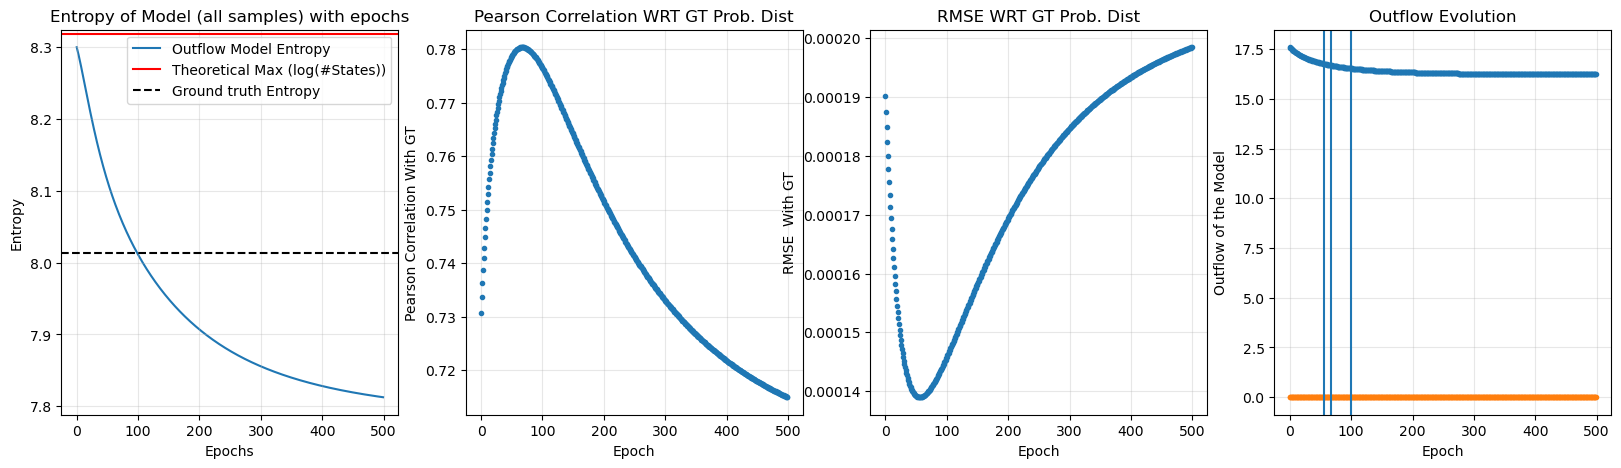

In [7711]:
fig, ax = plt.subplots(1,4, figsize=(20,5))

ax[0].plot(Entropy_evol_van, label = "Outflow Model Entropy", zorder = 0)
ax[0].grid(alpha = 0.3)
ax[0].axhline(np.log(Num_states), color = "red", label = "Theoretical Max (log(#States))")
ax[0].axhline(Actual_Entropy_GT, color = "black", linestyle = "dashed",label = "Ground truth Entropy")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Entropy")
ax[0].set_title("Entropy of Model (all samples) with epochs")
ax[0].legend()
#plt.xlim(0,100)

ax[1].plot(Pearson_prob, ".")
ax[1].grid(alpha = 0.3)
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Pearson Correlation With GT")
ax[1].set_title("Pearson Correlation WRT GT Prob. Dist")


ax[2].plot(RMSE_prob, ".")
ax[2].grid(alpha = 0.3)
ax[2].set_xlabel("Epoch")
ax[2].set_ylabel("RMSE  With GT")
ax[2].set_title("RMSE WRT GT Prob. Dist")


ax[3].plot(Outflow_out, ".")
ax[3].grid(alpha = 0.3)
ax[3].set_xlabel("Epoch")
ax[3].set_ylabel("Outflow of the Model")
ax[3].set_title("Outflow Evolution")

for i in range(0,3):
    ax[3].axvline(Arg_list[i])


plt.show()

In [7712]:
len(Sample_Prob_Evolution_van[0])
len(Emp_prob_k)

282

45


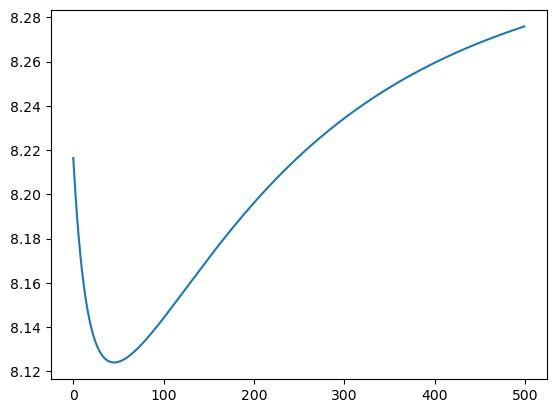

In [7713]:
def Cross_Ent(P, Q):
    kld = np.sum(-1 * P * np.log(Q))
    return kld

### What about GT and Probability_Array Cross Entropy?
C_ent_GT=[]
for p in Probability_Array_Evolution_van:

    C_p = Cross_Ent(Probability_of_States, p)

    C_ent_GT.append(C_p)


plt.plot(C_ent_GT)
print(np.argmin(C_ent_GT))

np.int64(499)

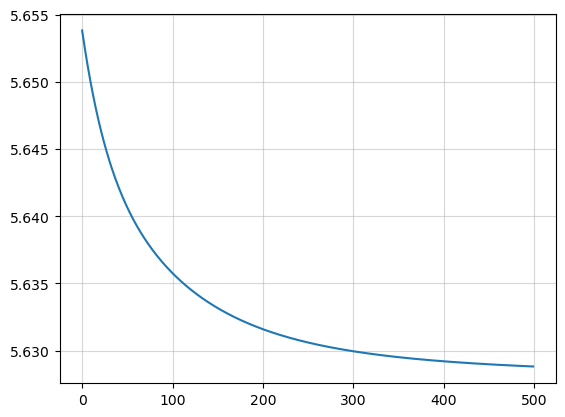

In [7716]:
C_ent = []
for p in Sample_Prob_Evolution_van:
    k = Cross_Ent(p,Emp_prob_k)
    plt.grid(alpha = 0.5)
    C_ent.append(k)

plt.plot(C_ent)
np.argmin(C_ent)

In [7720]:
Outflow_out_arr = np.array(Outflow_out)

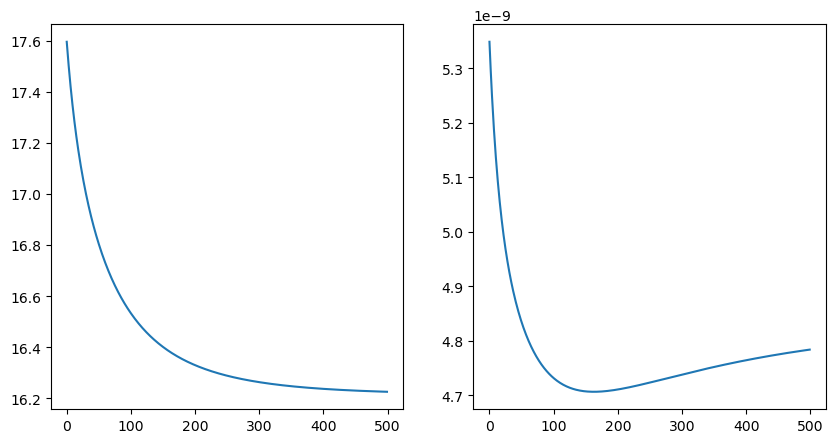

In [7721]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].plot(Outflow_out_arr[:,0])
ax[1].plot(Outflow_out_arr[:,1])


In [7722]:
print(Entropy_arg)
print(np.argmin(Outflow_out_arr[:,1]))

99
163


In [7723]:
Sample_Entropy_computed = Potts_out.compute_empirical_entropy()
Diff = Sample_Entropy_computed[0] - Sample_Entropy_computed[2]
print("Empirical Entropy=", Sample_Entropy_computed)
print("Miller-Madow corrected Entropy=", Sample_Entropy_computed[2])
#print("Training model Sample Entropy= ",Sample_Entropy_computed)

print("GT model Sample Entropy= ", GT_Entropy_Array[st])
print("Actual GT Entropy=",Actual_Entropy_GT)

Empirical Entropy= (5.620604812989008, 5.641907070938114, 5.152271479655674, 0.021302257949106007)
Miller-Madow corrected Entropy= 5.152271479655674
GT model Sample Entropy=  5.340523596520241
Actual GT Entropy= 8.013079961400368


-------------------------------------
-------------- Sample Probability Pearson --------------
Empirical Pearson match with Model Pearson = 499
Pearson val = 0.7149100442520222
RMSE val = 0.00019847630477946263
Entropy val = 7.8127475595390665


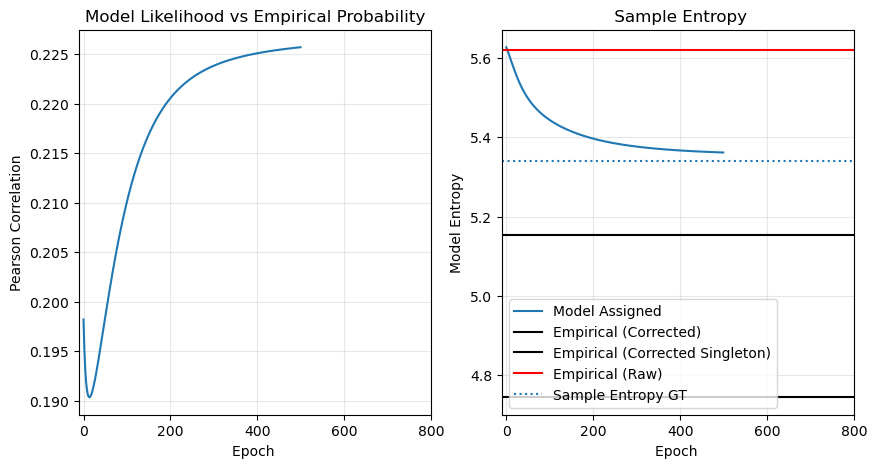

499
499
-------------------------------------
-------------- Sample Entropy Match --------------
Empirical Entropy match with Model Entropy = 499
Pearson val = 0.7149100442520222
RMSE val = 0.00019847630477946263
Entropy val = 7.8127475595390665


In [7724]:
Sample_Prob = Probability_Array_Evolution_van[:, Unique_index]
Cross_E = []
Sample_Prob_Norm = []
Pearson_with_sample=[]
S_entropy=[]
RMSE_with_sample = []
for s in Sample_Prob:
    s/=np.sum(s)
    Sample_Prob_Norm.append(s)
    p_val = pearsonr(s, Emp_prob_k)[0]
    rmse_val = np.sqrt(np.mean((s-Emp_prob_k)**2))

    cross = Cross_Ent(s, Emp_prob_k) + Cross_Ent(Emp_prob_k, s) 
    Cross_E.append(cross)
    Pearson_with_sample.append(p_val)
    RMSE_with_sample.append(rmse_val)

    ent = np.sum(-1* s * np.log(s))
    S_entropy.append(ent)
Sample_Prob = np.array(Sample_Prob)


print("-------------------------------------")
print("-------------- Sample Probability Pearson --------------")
print("Empirical Pearson match with Model Pearson =", np.argmax(Pearson_with_sample))

print("Pearson val =", Pearson_prob[ np.argmax(Pearson_with_sample)])

print("RMSE val =", RMSE_prob[ np.argmax(Pearson_with_sample)])

print("Entropy val =", Entropy_evol_van[ np.argmax(Pearson_with_sample)])




fig, ax = plt.subplots(1,2,figsize=(10,5))

ax[0].plot(Pearson_with_sample)
ax[0].set_xlabel("Epoch ")
ax[0].set_ylabel("Pearson Correlation")
ax[0].set_title("Model Likelihood vs Empirical Probability")

ax[1].plot(S_entropy, label = "Model Assigned ")

ax[1].axhline(Sample_Entropy_computed[2], label = "Empirical (Corrected)", color = "black")
ax[1].axhline(P[st], label = "Empirical (Corrected Singleton)", color = "black")
#ax[1].axhline(Sample_Entropy_computed[2]- Diff, label = "Empirical (Corrected (2))", color = "orange")

ax[1].axhline(Sample_Entropy_computed[0], label = "Empirical (Raw)", color = "red")

ax[1].axhline(GT_Entropy_Array[st], linestyle = "dotted", label = "Sample Entropy GT")
ax[1].set_title(" Sample Entropy")
ax[1].set_xlabel("Epoch ")
ax[1].set_ylabel("Model Entropy")
ax[0].grid(alpha = 0.3)
ax[1].grid(alpha = 0.3)

ax[0].set_xlim(-10,800)
ax[1].set_xlim(-10,800)
ax[1].legend()
plt.show()

Arg_s_ent = np.argmin(np.abs(np.array(S_entropy) -P[st]))
Arg_pear = np.argmax(Pearson_with_sample)
print(Arg_s_ent)
print(Arg_pear)

print("-------------------------------------")
print("-------------- Sample Entropy Match --------------")
print("Empirical Entropy match with Model Entropy =", Arg_s_ent)

print("Pearson val =", Pearson_prob[ Arg_s_ent])

print("RMSE val =", RMSE_prob[ Arg_s_ent])

print("Entropy val =", Entropy_evol_van[ Arg_s_ent])


In [7725]:

print("Empirical Entropy=", Sample_Entropy_computed)
print("Miller-Madow corrected Entropy=", Sample_Entropy_computed[2])
#print("Training model Sample Entropy= ",Sample_Entropy_computed)

print("GT model Sample Entropy= ", GT_Entropy_Array[st])
print("Actual GT Entropy=",Actual_Entropy_GT)

print("--------")
print(np.argmin(np.abs(np.array(S_entropy) -  GT_Entropy_Array[st])))

Empirical Entropy= (5.620604812989008, 5.641907070938114, 5.152271479655674, 0.021302257949106007)
Miller-Madow corrected Entropy= 5.152271479655674
GT model Sample Entropy=  5.340523596520241
Actual GT Entropy= 8.013079961400368
--------
499


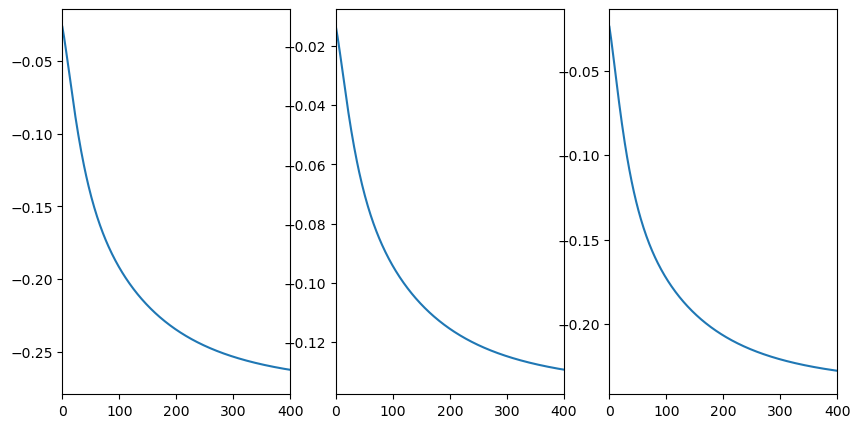

In [7726]:
## What about KL divergence or JS divergence?
def KL_Divergence(P, Q):
    kld = np.sum(-1 * P * np.log(P/Q))
    return kld

def JS_Divergence(P, Q):
    P_mean = (P + Q)/2
    jsd = np.sum(-1 * P * np.log(P/P_mean)) + np.sum(-1 * Q * np.log(Q/P_mean))
    return jsd

def PR_Divergence(P, Q):
    P_r = ((P/Q) + (Q/P))*0.5
    prd = np.sum(-1 * P * np.log(P_r)) 
    return prd


KLD=[]
JSD=[]
PRD = []
for p in Sample_Prob:
    k = KL_Divergence(p,Emp_prob_k)
    j = JS_Divergence(p,Emp_prob_k)
    p = PR_Divergence(p, Emp_prob_k)

    KLD.append(k)
    JSD.append(j)
    PRD.append(p)
fig, ax = plt.subplots(1,3, figsize=(10,5))
ax[0].plot(KLD)
ax[1].plot(JSD)
ax[2].plot(PRD)
for i in range(0,3):
    ax[i].set_xlim(0,400)



In [7727]:
Deriv = (np.gradient(PRD))

Deriv[30:86]

def Sign_change(Deriv):
    Arg_extreme=[]
    for i in range(0, len(Deriv)-1):
        if np.sign(Deriv[i]) != np.sign(Deriv[i+1]):
            Arg_extreme.append(i)
    return np.array(Arg_extreme)


In [7728]:
print(Sign_change(np.gradient(KLD)))
print(Sign_change(np.gradient(JSD)))
print(Sign_change(np.gradient(PRD)))

[]
[]
[]


In [7729]:

print("----------------------------------")
print("------------- Pearson -------------")
print("Max Arg According to Pearson=", Pearson_arg)

print("Pearson val =", Pearson_prob[Pearson_arg])

print("RMSE val =", RMSE_prob[Pearson_arg])

print("Entropy val =", Entropy_evol_van[Pearson_arg])


print("----------------------------------")
print("-------------- RMSE --------------")
print("Max Arg According to RMSE=", RMSE_arg)

print("Pearson val =", Pearson_prob[RMSE_arg])

print("RMSE val =", RMSE_prob[RMSE_arg])

print("Entropy val =", Entropy_evol_van[RMSE_arg])



print("-------------------------------------")
print("-------------- Entropy --------------")
print("Entropy Closest to GT =", Entropy_arg)

print("Pearson val =", Pearson_prob[Entropy_arg])

print("RMSE val =", RMSE_prob[Entropy_arg])

print("Entropy val =", Entropy_evol_van[Entropy_arg])



print("-------------------------------------")
print("-------------- Sample Entropy Match --------------")
print("Empirical Entropy match with Model Entropy =", Arg_s_ent)

print("Pearson val =", Pearson_prob[ Arg_s_ent])

print("RMSE val =", RMSE_prob[ Arg_s_ent])

print("Entropy val =", Entropy_evol_van[ Arg_s_ent])


print("-------------------------------------")
print("-------------- Final values ---------")

print("Pearson val =", Pearson_prob[-1])

print("RMSE val =", RMSE_prob[-1])

print("Entropy val =", Entropy_evol_van[-1])


----------------------------------
------------- Pearson -------------
Max Arg According to Pearson= 67
Pearson val = 0.7803881799515084
RMSE val = 0.0001396251027574825
Entropy val = 8.071465040486551
----------------------------------
-------------- RMSE --------------
Max Arg According to RMSE= 56
Pearson val = 0.7797467471280972
RMSE val = 0.00013897377762692116
Entropy val = 8.097583311413485
-------------------------------------
-------------- Entropy --------------
Entropy Closest to GT = 99
Pearson val = 0.7766775865058604
RMSE val = 0.00014559997320517964
Entropy val = 8.012602286613168
-------------------------------------
-------------- Sample Entropy Match --------------
Empirical Entropy match with Model Entropy = 499
Pearson val = 0.7149100442520222
RMSE val = 0.00019847630477946263
Entropy val = 7.8127475595390665
-------------------------------------
-------------- Final values ---------
Pearson val = 0.7149100442520222
RMSE val = 0.00019847630477946263
Entropy val = 7.

In [7730]:
Dev2 =(np.gradient(np.gradient(Outflow_out)))


Text(0.5, 1.0, 'Final Probability (Epoch = 500)')

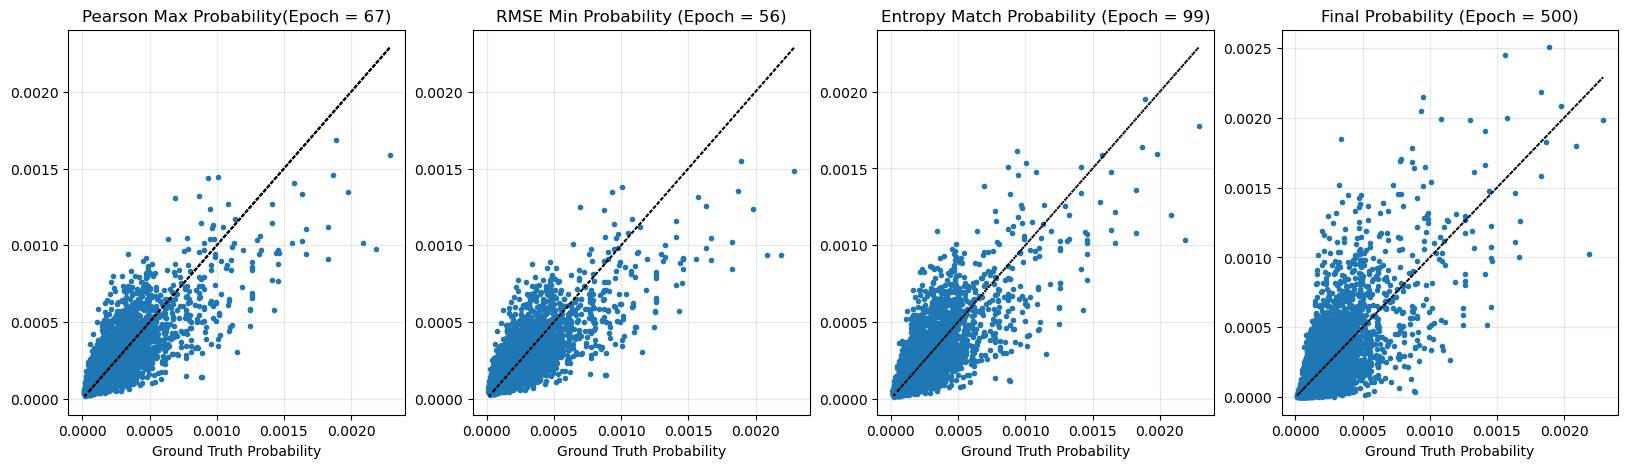

In [7731]:
fig, ax = plt.subplots(1,4,figsize= (20,5))
Arg_list = [Pearson_arg, RMSE_arg, Entropy_arg, -1]

ax[0].plot(Probability_of_States, Probability_Array_Evolution_0[Pearson_arg], ".")

for i in range(0,4):
    arg_i = Arg_list[i]

    ax[i].plot(Probability_of_States,Probability_of_States, color="black", linestyle= "dotted", zorder = 3)
    ax[i].set_xlabel("Ground Truth Probability")
    
    ax[i].grid(alpha = 0.3)


ax[1].plot(Probability_of_States, Probability_Array_Evolution_0[RMSE_arg], ".")

ax[0].plot(Probability_of_States,Probability_of_States, color="black", linestyle= "dotted")
ax[2].plot(Probability_of_States, Probability_Array_Evolution_0[Entropy_arg], ".")

ax[3].plot(Probability_of_States, Probability_Array_Evolution_0[-1], ".")

ax[0].set_title(f"Pearson Max Probability(Epoch = {Arg_list[0]})")
ax[1].set_title(f"RMSE Min Probability (Epoch = {Arg_list[1]})")
ax[2].set_title(f"Entropy Match Probability (Epoch = {Arg_list[2]})")
ax[3].set_title(f"Final Probability (Epoch = {len(Outflow_out)})")

In [7641]:
Potts_out_exp = Compressed_Potts_Quadratic(Chosen_Data, compressed=False)
Outflow_out_exp=[]
Netflow_out_exp=[]
Probability_Array_Evolution_1 = []
Sample_Prob_Evolution_1 = []



Number of Partitions Set= 1
..Setting Partition Map..
Number of partitions = 1
Initializing with score matching ...
Initializing with score matching ...


In [7642]:
Exp_used = 0

method = 1

lr = 0.01
#n_epochs = Arg_stop
n_epochs = 126
Train = True
if Train:
    for i in tqdm(range(0, n_epochs)):
        out, net = Potts_out_exp.Exact_Min_Outflow_Single_Iteration_Parameter_Update(Property, lr, method = method, power=Exp_used)
        Outflow_out_exp.append(out)
        Netflow_out_exp.append(net)

        Energy_of_States_out_exp_i = Potts_Energy_of_State_Array(Unfurled_States, Potts_out_exp.Weights[0], Potts_out_exp.Bias[0])
        Prob_i = Potts_Probability_of_State_Array(Energy_of_States_out_exp_i, 1)
        Probability_Array_Evolution_1.append(Prob_i)


        Sample_States_energy_i = Potts_Energy_of_State_Array(Potts_out_exp.unfurled_data, Potts_out_exp.Weights[0], Potts_out_exp.Bias[0])
        Prob_samp_i = Potts_Probability_of_State_Array(Sample_States_energy_i, 1)
        Sample_Prob_Evolution_1.append(Prob_samp_i)

        
    print("Training_Method =", Potts_out_exp.method)

else:
    print("Training is Off!")
        

100%|██████████| 126/126 [00:00<00:00, 549.40it/s]

Training_Method = Outflow


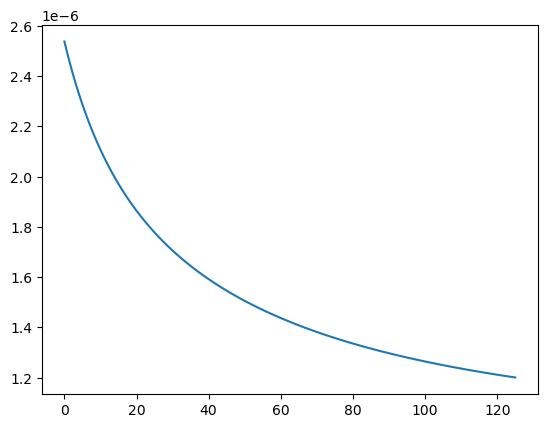

In [7643]:
#plt.plot(np.array(Outflow_out_exp))
plt.plot(np.array(Netflow_out_exp))



In [7644]:
np.argmin(Netflow_out_exp)

np.int64(125)

In [7645]:

Probability_Array_Evolution_Exp = np.array(Probability_Array_Evolution_1)
Entropy_evol_Exp = np.sum(-1 * Probability_Array_Evolution_Exp * np.log(Probability_Array_Evolution_Exp), axis = 1)


Sample_Prob_Evolution_Exp = np.array(Sample_Prob_Evolution_1)
Sample_Entropy_evol_Exp = np.sum(-1 * Sample_Prob_Evolution_Exp * np.log(Sample_Prob_Evolution_Exp), axis = 1)


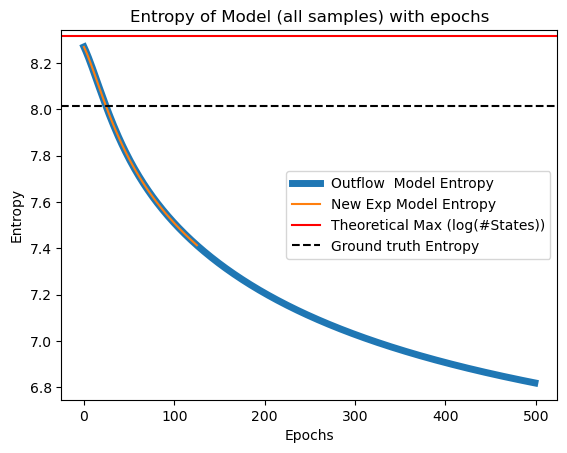

In [7646]:

plt.plot(Entropy_evol_van, label = "Outflow  Model Entropy", zorder = 0, linewidth = 5)
plt.plot(Entropy_evol_Exp, label = "New Exp Model Entropy")
plt.axhline(np.log(Num_states), color = "red", label = "Theoretical Max (log(#States))")
plt.axhline(Actual_Entropy_GT, color = "black", linestyle = "dashed",label = "Ground truth Entropy")
plt.xlabel("Epochs")
plt.ylabel("Entropy")
plt.title("Entropy of Model (all samples) with epochs")
plt.legend()
#plt.xlim(0,100)

----------------
Delta Flow_out= [1.49775711e-03 7.16483724e-11]
Delta Flow_exp= 0.01070428422641534
----------------


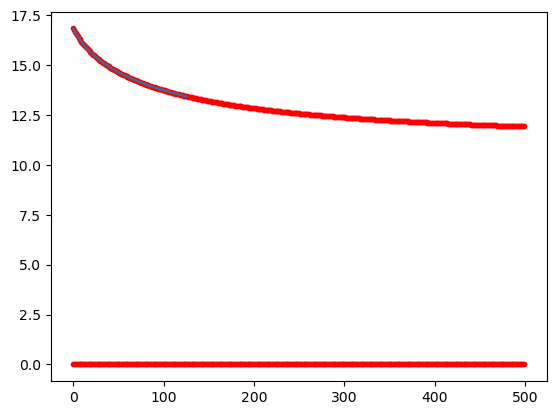

In [7650]:
print("----------------")
print("Delta Flow_out=", Outflow_out_arr[-2]- Outflow_out_arr[-1])

print("Delta Flow_exp=", Outflow_out_exp[-2]- Outflow_out_exp[-1])
print("----------------")

plt.plot(Outflow_out_exp)


plt.plot(Outflow_out, ".-", color = "red", zorder =0)

In [7651]:
Energy_of_States_out = Potts_Energy_of_State_Array(Unfurled_States, Potts_out.Weights[0], Potts_out.Bias[0])
Energy_of_States_out_exp = Potts_Energy_of_State_Array(Unfurled_States, Potts_out_exp.Weights[0], Potts_out_exp.Bias[0])

In [7652]:
Prob_out = Potts_Probability_of_State_Array(Energy_of_States_out, 1)
Prob_out_exp = Potts_Probability_of_State_Array(Energy_of_States_out_exp, 1)

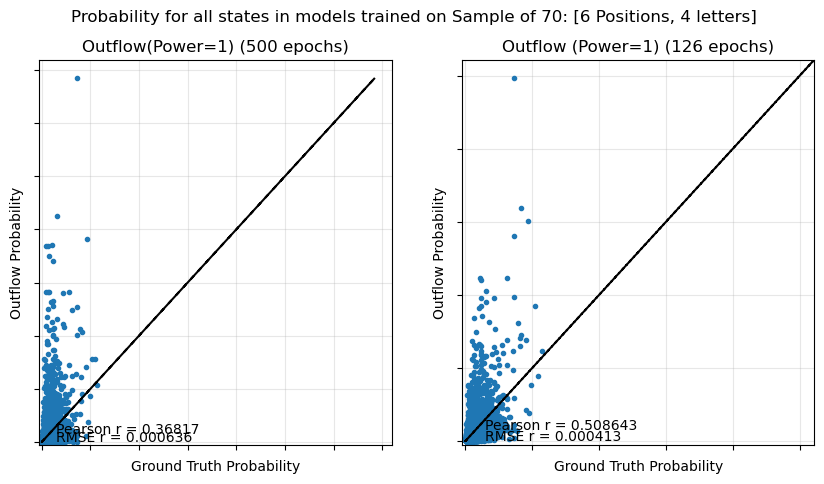

RMSE_out= 0.000636
Pearson_out= 0.36817
RMSE_out_exp= 0.000413
Pearson_out_exp= 0.508643


In [7653]:
fig, ax = plt.subplots(1,2,figsize=(10,5))
num_round = 6
ax[0].plot(Probability_of_States, Prob_out, ".")
ax[0].plot(Prob_out, Prob_out, "k--")
ax[0].set_xlim(-0.0001, 1.05*np.max([Probability_of_States, Prob_out]))
ax[0].set_ylim(-0.0001, 1.05*np.max([Probability_of_States, Prob_out]))

RMSE_out = np.round(np.sqrt(np.mean((Probability_of_States-Prob_out)**2)),num_round)
Pearson_out = np.round(pearsonr(Probability_of_States,Prob_out)[0],num_round)


ax[1].plot(Probability_of_States, Prob_out_exp, ".")
ax[1].plot(Prob_out, Prob_out, "k--")

ax[1].set_xlim(-0.0001, 1.05*np.max([Probability_of_States, Prob_out_exp]))
ax[1].set_ylim(-0.0001, 1.05*np.max([Probability_of_States, Prob_out_exp]))

RMSE_out_exp = np.round(np.sqrt(np.mean((Probability_of_States-Prob_out_exp)**2)),num_round)
Pearson_out_exp = np.round(pearsonr(Probability_of_States,Prob_out_exp)[0],num_round)


x_val = 0.0006
y_val = 0.0003
step =0.0003
ax[1].text(s=f"Pearson r = {np.round(Pearson_out_exp,6)}", x=x_val, y = y_val)
ax[1].text(s=f"RMSE r = {np.round(RMSE_out_exp,6)}", x=x_val, y = y_val - step)

ax[0].text(s=f"Pearson r = {np.round(Pearson_out,6)}", x=x_val, y = y_val)
ax[0].text(s=f"RMSE r = {np.round(RMSE_out,6)}", x=x_val, y = y_val-step)


ax[0].set_xlabel("Ground Truth Probability")
ax[0].set_ylabel("Outflow Probability")
ax[0].grid(alpha =0.3)
ax[0].set_xticklabels([])
ax[0].set_yticklabels([])

ax[1].set_xlabel("Ground Truth Probability")
ax[1].set_ylabel("Outflow Probability")
ax[1].set_xticklabels([])
ax[1].set_yticklabels([])
ax[1].grid(alpha =0.3)
ax[0].set_title(f"Outflow(Power=1) ({len(Outflow_out)} epochs)")
ax[1].set_title(f"Outflow (Power={1}) ({len(Outflow_out_exp)} epochs)")
plt.suptitle(f"Probability for all states in models trained on Sample of {Sample_Size[st]}: [{Num_site} Positions, {Num_letter} letters]")
plt.show()

print("RMSE_out=",RMSE_out)
print("Pearson_out=",Pearson_out)
print("RMSE_out_exp=",RMSE_out_exp)
print("Pearson_out_exp=",Pearson_out_exp)

In [7654]:
Num_unique[st]

67

In [7655]:
### Quality of Samples:
num_samp = 7000
Labels = ["GT_1", "GT_2", "Out", "Out_Exp"]

Sampled={}


GT_Sample_1 = Sample_From_Distribution(num_samp, Unfurled_States, Probability_of_States)
GT_Sample_2 = Sample_From_Distribution(num_samp, Unfurled_States, Probability_of_States)

Out_Sample = Sample_From_Distribution(num_samp, Unfurled_States, Prob_out)
Out_Exp_Sample = Sample_From_Distribution(num_samp, Unfurled_States, Prob_out_exp)

Sampled[Labels[0]]= GT_Sample_1
Sampled[Labels[1]]= GT_Sample_2
Sampled[Labels[2]] = Out_Sample
Sampled[Labels[3]] = Out_Exp_Sample

In [7656]:
Sing_Freq={}
PW_Freq={}
PW_Corr = {}
Trip_Corr={}

for l in Labels:
    Data = Sampled[l]['Chosen_Compact_States']
    Sing_Freq[l] = Singlet_Frequency(Data, Num_letter)
    PW_Freq[l], _ = Pairwise_Frequency(Data, Num_letter)
    PW_Corr[l], _ = Pairwise_Correlation(Data, Num_letter)
    Trip_Corr[l] = Triplet_Correlation(Data, Num_letter)
    
Pearson_vals={}
RMSE_vals = {}


for l in Labels[1:]:

    Gt_sing = Sing_Freq['GT_1']
    Gt_pwf= PW_Freq['GT_1']
    Gt_pwc= PW_Corr['GT_1']
    Gt_tc= Trip_Corr['GT_1']

    O_sing = Sing_Freq[l]
    O_pwf= PW_Freq[l]
    O_pwc= PW_Corr[l]
    O_tc= Trip_Corr[l]

    Pearson_sing = pearsonr(Gt_sing, O_sing)[0]
    Pearson_pwf = pearsonr(Gt_pwf, O_pwf)[0]
    Pearson_pwc = pearsonr(Gt_pwc, O_pwc)[0]
    Pearson_tc = pearsonr(Gt_tc, O_tc)[0]
    Pearson = [Pearson_sing,Pearson_pwf,Pearson_pwc ,Pearson_tc]
    Pearson_vals[l] = Pearson


    RMSE_sing = np.sqrt(np.mean((Gt_sing- O_sing)**2))
    RMSE_pwf = np.sqrt(np.mean((Gt_pwf- O_pwf)**2))
    RMSE_pwc = np.sqrt(np.mean((Gt_pwc- O_pwc)**2))
    RMSE_tc = np.sqrt(np.mean((np.array(Gt_tc)- np.array(O_tc))**2))
    RMSE = [RMSE_sing, RMSE_pwf, RMSE_pwc, RMSE_tc]

    RMSE_vals[l] = RMSE



Text(0, 0.5, 'Ground Truth Sampled-2')

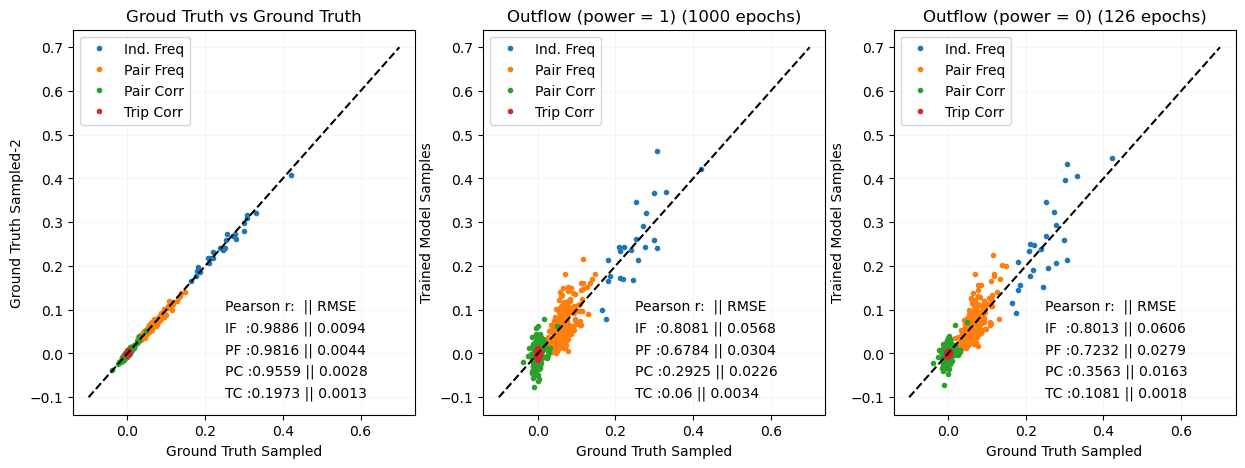

In [7657]:
fig, ax = plt.subplots(1,3,figsize= (15,5))


ax[0].plot(Sing_Freq['GT_1'], Sing_Freq['GT_2'], ".", label="Ind. Freq")
ax[0].plot(PW_Freq['GT_1'], PW_Freq['GT_2'], ".", label = "Pair Freq")
ax[0].plot(PW_Corr['GT_1'], PW_Corr['GT_2'], ".", label = "Pair Corr")
ax[0].plot(Trip_Corr['GT_1'], Trip_Corr['GT_2'], ".", label = "Trip Corr")
ax[0].set_title(f"Groud Truth vs Ground Truth")
ax[0].plot(np.arange(-0.1,0.71,0.1), np.arange(-0.1,0.71,0.1), color = "black", linestyle = "dashed")
ax[0].legend(loc = "upper left")
ax[0].grid(alpha = 0.1)

ax[1].plot(Sing_Freq['GT_1'], Sing_Freq['Out'], ".", label="Ind. Freq")
ax[1].plot(PW_Freq['GT_1'], PW_Freq['Out'], ".", label = "Pair Freq")
ax[1].plot(PW_Corr['GT_1'], PW_Corr['Out'], ".", label = "Pair Corr")
ax[1].plot(Trip_Corr['GT_1'], Trip_Corr['Out'], ".", label = "Trip Corr")
ax[1].plot(np.arange(-0.1,0.71,0.1), np.arange(-0.1,0.71,0.1), color = "black", linestyle = "dashed")
ax[1].legend(loc = "upper left")
ax[1].set_title(f"Outflow (power = 1) (1000 epochs)")
ax[1].grid(alpha = 0.1)

ax[2].plot(Sing_Freq['GT_1'], Sing_Freq['Out_Exp'], ".", label="Ind. Freq")
ax[2].plot(PW_Freq['GT_1'], PW_Freq['Out_Exp'], ".", label = "Pair Freq")
ax[2].plot(PW_Corr['GT_1'], PW_Corr['Out_Exp'], ".", label = "Pair Corr")
ax[2].plot(Trip_Corr['GT_1'], Trip_Corr['Out_Exp'], ".", label = "Trip Corr")
ax[2].set_title(f"Outflow (power = {Exp_used}) ({len(Outflow_out_exp)} epochs)")
ax[2].plot(np.arange(-0.1,0.71,0.1), np.arange(-0.1,0.71,0.1), color = "black", linestyle = "dashed")
ax[2].legend(loc = "upper left")
ax[2].grid(alpha = 0.1)



loc_x = 0.25
loc_y = 0.1
step = 0.05


for i in range(0,3):
    ax[i].set_xlabel("Ground Truth Sampled")
    ax[i].set_ylabel("Trained Model Samples")
    ax[i].text(x=loc_x, y = loc_y, s = "Pearson r:  || RMSE")
    ax[i].text(x=loc_x, y = loc_y - 1*step, s = f"IF  :{np.round(Pearson_vals[Labels[1:][i]][0], 4)} || {np.round(RMSE_vals[Labels[1:][i]][0], 4)}")
    ax[i].text(x=loc_x, y = loc_y - 2*step, s = f"PF :{np.round(Pearson_vals[Labels[1:][i]][1], 4)} || {np.round(RMSE_vals[Labels[1:][i]][1], 4)}")
    ax[i].text(x=loc_x, y = loc_y - 3*step, s = f"PC :{np.round(Pearson_vals[Labels[1:][i]][2], 4)} || {np.round(RMSE_vals[Labels[1:][i]][2], 4)}")
    ax[i].text(x=loc_x, y = loc_y - 4*step, s = f"TC :{np.round(Pearson_vals[Labels[1:][i]][3], 4)} || {np.round(RMSE_vals[Labels[1:][i]][3], 4)}")

ax[0].set_ylabel("Ground Truth Sampled-2")

In [7658]:
P1 =Probability_of_States

In [7267]:
Cross_ent= []
for p_st in Probability_Array_Evolution_0:
    Cross_ent.append(Cross_Ent(Probability_of_States, p_st))
    #Cross_ent.append(KL_Divergence(Probability_of_States, p_st))


In [7268]:
np.argmin(Cross_ent)

np.int64(96)

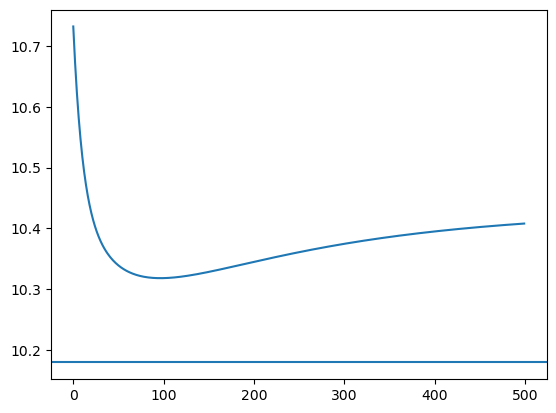

In [7270]:
plt.plot(Cross_ent)
plt.axhline(Actual_Entropy_GT)

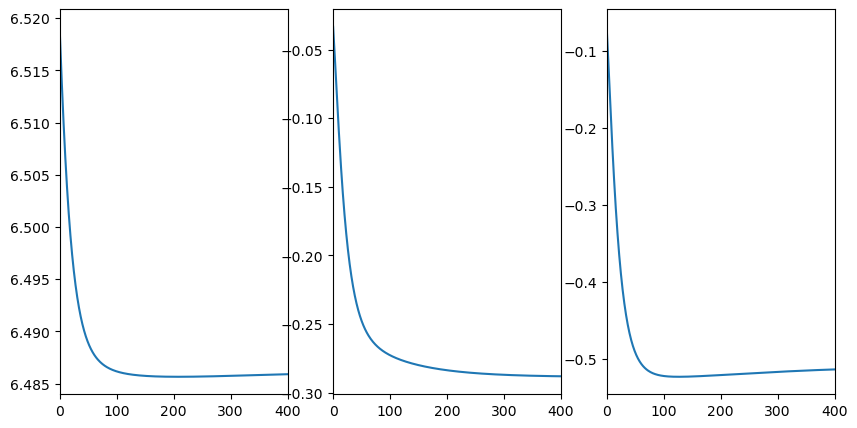

In [7272]:
KLD=[]
JSD=[]
PRD = []
for p in Sample_Prob:
    k = Cross_Ent(p,Emp_prob_k)
    j = JS_Divergence(p,Emp_prob_k)
    p = PR_Divergence(p, Emp_prob_k)

    KLD.append(k)
    JSD.append(j)
    PRD.append(p)
fig, ax = plt.subplots(1,3, figsize=(10,5))
ax[0].plot(KLD)
ax[1].plot(JSD)
ax[2].plot(PRD)
for i in range(0,3):
    ax[i].set_xlim(0,400)

In [7274]:
np.argmin(KLD)

np.int64(208)